In [46]:
from copy import deepcopy
from functools import partial
from typing import Callable, Tuple

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.utils import tree_replace

In [24]:
SEED = 0
INPUT_DIM = 20
TARGET_NOISE = 0.1

In [47]:
def make_task():
    rng = jax.random.PRNGKey(SEED)
    return FeatureSiftingTask(n_learner_features=INPUT_DIM, target_noise_std=TARGET_NOISE, key=rng)


class LearnerState(eqx.Module):
    weights: jax.Array


@partial(jax.jit, static_argnames=('update_fn', 'steps'))
def run_train_loop(
    update_fn: Callable[[LearnerState, np.ndarray, np.ndarray], Tuple[LearnerState, np.ndarray]],
    learner_state: LearnerState,
    task: FeatureSiftingTask,
    steps: int,
):
    def _train_step(carry, _):
        learner_state, task, x, y = carry
        
        ### Forward pass ###
        pred = x @ learner_state.weights
        error = y - pred
        loss = error ** 2
        
        ### Update ###
        learner_state, prune_mask = update_fn(learner_state, x, y)
        
        ### New sample ###
        task, (x, y) = task.step(prune_mask)
        
        return (learner_state, task, x, y), {
            'losses': loss,
        }
    
    task, (x, y) = task.step(jnp.zeros(INPUT_DIM))
    learner_state, metrics = jax.lax.scan(
        _train_step,
        (learner_state, task, x, y),
        length = steps,
    )
    
    return metrics

In [49]:
class LMSState(LearnerState):
    step_size: float

### Task init ###
task = make_task()

### Parameters ###
train_steps = 10000

### Hyperparameters ###
step_size = 0.01

### Network init ###
weights = np.zeros(INPUT_DIM)
algo_state = LMSState(weights, step_size)

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = np.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask

run_train_loop(lms_update, algo_state, task, train_steps)

{'losses': Array([[3.1623387 ],
        [0.00452587],
        [3.8105257 ],
        ...,
        [0.42613068],
        [0.9784223 ],
        [2.705481  ]], dtype=float32)}

In [ ]:
class LMSState(LearnerState):
    step_size: float

### Task init ###
task = make_task()

### Parameters ###
train_steps = 10000

### Hyperparameters ###
step_size = 0.01

### Network init ###
weights = np.zeros(INPUT_DIM)
algo_state = LMSState(weights, step_size)

def lms_update(learner_state, x, y):
    pred = x @ learner_state.weights
    error = y - pred
    grad = error * -x
    new_weights = learner_state.weights - learner_state.step_size * grad
    prune_mask = np.zeros(INPUT_DIM)
    new_state = tree_replace(learner_state, weights=new_weights)
    return new_state, prune_mask

run_train_loop(lms_update, algo_state, task, train_steps)

# V1: LMS

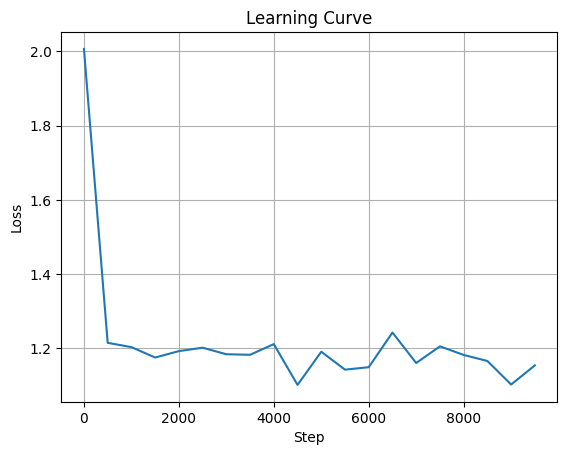

In [ ]:
### Task init ###
task = make_task()
x, y = task.step(np.zeros(INPUT_DIM))

### Parameters ###
step_size = 0.01
train_steps = 10000
log_freq = 500

### Network init ###
weights = np.zeros(INPUT_DIM)

lms_results = dict(
    losses = [],
)

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    lms_results['losses'].append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### New sample ###
    x, y = task.step(np.zeros(INPUT_DIM))
        

lms_results['binned_losses'] = np.array(lms_results['losses']).reshape(-1, log_freq)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.plot(np.arange(train_steps)[::log_freq], lms_results['binned_losses'].mean(axis=1))
plt.grid(True)
plt.show()



# V2: Simple Utility-Based Pruning

This is the simplest version of a utility-based pruning algorithm I can think of, that only introduces one more hyperparameter.

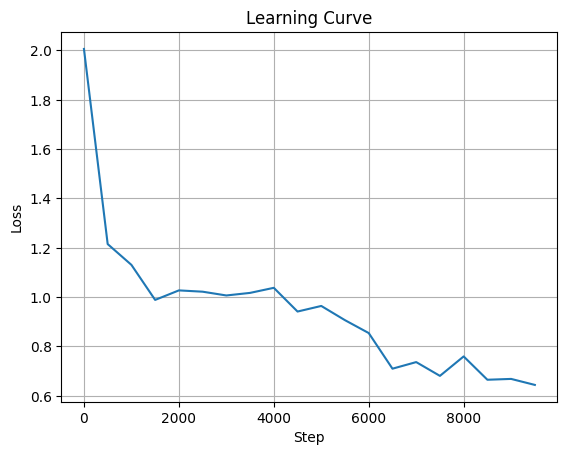

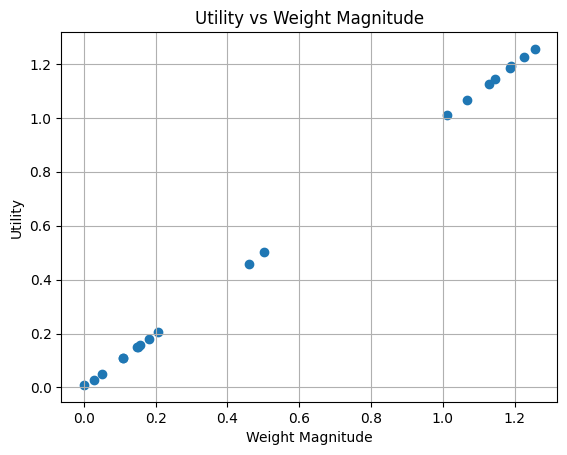

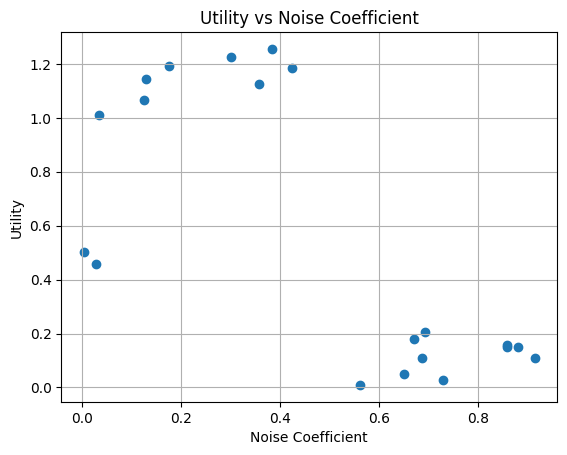

In [ ]:
### Task init ###
task = make_task()
x, y = task.step(np.zeros(INPUT_DIM))

### Problem Parameters ###
train_steps = 10000
log_freq = 500

### Hyperparameters ###
step_size = 0.01
prune_freq = 1000

### Network init ###
weights = np.zeros(INPUT_DIM)

v2_results = dict(
    losses = [],
)

for i in range(train_steps):
    
    ### Forward pass ###
    pred = x @ weights
    error = y - pred
    loss = error ** 2
    v2_results['losses'].append(loss)
    
    ### Backward pass ###
    grad = error * -x
    weights -= step_size * grad
    
    ### Pruning ###
    prune_mask = np.zeros(INPUT_DIM)
    if (i + 1) % prune_freq == 0:
        utilities = np.abs(weights)
        lowest_idx = np.argmin(utilities)
        weights[lowest_idx] = 0
        prune_mask[lowest_idx] = 1
    
    ### New sample ###
    x, y = task.step(prune_mask)
        

v2_results['binned_losses'] = np.array(v2_results['losses']).reshape(-1, log_freq)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.plot(np.arange(train_steps)[::log_freq], v2_results['binned_losses'].mean(axis=1))
plt.grid(True)
plt.show()

plt.scatter(np.abs(weights), utilities)
plt.xlabel('Weight Magnitude')
plt.ylabel('Utility')
plt.title('Utility vs Weight Magnitude')
plt.grid(True)
plt.show()

plt.scatter(task.noise_coefficients, utilities)
plt.xlabel('Noise Coefficient')
plt.ylabel('Utility')
plt.title('Utility vs Noise Coefficient')
plt.grid(True)
plt.show()

